# Aufgabe: Advanced Hyperparameter

### Aufgabe 1

*Trainieren Sie ein beliebiges Modell mit PyTorch oder sklearn. Identifizieren Sie mit einem beliebigen Weg die schlechtesten und besten Hyperparameter eines Modells. Zeigen Sie die Spannweite zwischen maximaler und minimaler Genauigkeit eines Modells in Abhängigkeit von Hyperparametern*

In [1]:
import numpy as np
import pandas as pd  # Für das Laden und die Datenmanipulation
import matplotlib.pyplot as plt  # Für das Erstellen von Diagrammen

from sklearn.tree import DecisionTreeClassifier  # Unser gewähltes Modell
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)  # Für Datenaufteilung und Hyperparameter-Suche
from sklearn.preprocessing import (
    StandardScaler,
)  # Für Skalierung (nicht zwingend für Entscheidungsbäume, aber gute Praxis)
from sklearn.datasets import load_breast_cancer


In [2]:
# Laden des Breast Cancer Datensatzes
cancer = load_breast_cancer()

# Merkmale (X) und Zielvariable (y) extrahieren
X = pd.DataFrame(
    cancer.data, columns=cancer.feature_names
)  # Features als DataFrame für bessere Übersicht
y = pd.Series(cancer.target)  # Zielvariable als Series

# Anzeigen der ersten Zeilen des DataFrames und der Zielvariable
print("Erste 5 Zeilen der Features:")
print(X.head())

print("\nInformationen zu den Features:")
X.info()

print("\nTarget (y) Verteilung:")
print(y.value_counts())  # Anzahl der Samples pro Klasse

print("\nFeatures (X) Form: ", X.shape)
print("Target (y) Form: ", y.shape)

# Daten in Trainings- (80%) und Testsets (20%) aufteilen
# stratify=y ist hier besonders wichtig, da die Klassen leicht ungleich verteilt sind.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalierung der Features (Standardisierung)
# Für Entscheidungsbäume nicht zwingend notwendig, aber gute Praxis für die meisten ML-Modelle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX_train_scaled Form: ", X_train_scaled.shape)
print("X_test_scaled Form: ", X_test_scaled.shape)


Erste 5 Zeilen der Features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  wo

### Gridsearch

In [3]:
# Modell definieren
model = DecisionTreeClassifier(random_state=42)

# Hyperparameter-Grid definieren
# Wir erweitern die Bereiche leicht, um mehr Variation zu sehen
param_grid = {
    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        10,
        15,
        None,
    ],  # None bedeutet keine Tiefenbegrenzung
    "min_samples_leaf": [
        1,
        2,
        4,
        8,
        16,
        32,
    ],  # Kleinere bis größere Anforderungen an Blattgröße
}

print("Zu testende Hyperparameter-Kombinationen:\n")
# Zeigt die Anzahl der Kombinationen im Grid
total_combinations = 1
for key, values in param_grid.items():
    print(f"- {key}: {values}")
    total_combinations *= len(values)
print(
    f"\nGesamtzahl der Kombinationen: {total_combinations} Kombinationen werden getestet."
)


Zu testende Hyperparameter-Kombinationen:

- max_depth: [2, 3, 4, 5, 6, 7, 8, 10, 15, None]
- min_samples_leaf: [1, 2, 4, 8, 16, 32]

Gesamtzahl der Kombinationen: 60 Kombinationen werden getestet.


In [4]:
# GridSearchCV initialisieren
# estimator: Das Modell, das wir optimieren wollen
# param_grid: Das Dictionary mit den zu testenden Hyperparametern
# cv: Anzahl der Folds für die Kreuzvalidierung (z.B. 5-fach)
# scoring: Die Metrik zur Bewertung der Modellleistung (hier 'accuracy' für Klassifikation)
# n_jobs: Anzahl der parallel zu nutzenden CPU-Kerne (-1 bedeutet alle verfügbaren Kerne)
print("Starte Hyperparameter-Suche mit GridSearchCV...")
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

# Hyperparameter-Suche auf den Trainingsdaten durchführen
grid_search.fit(X_train_scaled, y_train)

print("\nHyperparameter-Suche beendet.")


Starte Hyperparameter-Suche mit GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits



Hyperparameter-Suche beendet.


In [5]:
# Beste Hyperparameter-Kombination
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Beste Hyperparameter: {best_params}")
print(f"Beste Genauigkeit (Kreuzvalidierung): {best_score:.4f}")

# Das beste Modell, das während der Suche gefunden wurde
best_model = grid_search.best_estimator_

# Ergebnisse aller getesteten Kombinationen
results_df = pd.DataFrame(grid_search.cv_results_)

# Sortieren nach Genauigkeit, um die schlechtesten zu finden
results_df_sorted = results_df.sort_values(by="mean_test_score", ascending=True)

# Schlechteste Hyperparameter-Kombination
worst_params = results_df_sorted.iloc[0]["params"]
worst_score = results_df_sorted.iloc[0]["mean_test_score"]
print(f"\nSchlechteste Hyperparameter: {worst_params}")
print(f"Schlechteste Genauigkeit (Kreuzvalidierung): {worst_score:.4f}")

# Spannweite der Genauigkeit
accuracy_range = best_score - worst_score
print(
    f"\nSpannweite zwischen maximaler und minimaler Genauigkeit: {accuracy_range:.4f}"
)
print(f"Maximale Genauigkeit: {best_score:.4f}")
print(f"Minimale Genauigkeit: {worst_score:.4f}")


Beste Hyperparameter: {'max_depth': 4, 'min_samples_leaf': 1}
Beste Genauigkeit (Kreuzvalidierung): 0.9385

Schlechteste Hyperparameter: {'max_depth': 6, 'min_samples_leaf': 32}
Schlechteste Genauigkeit (Kreuzvalidierung): 0.9033

Spannweite zwischen maximaler und minimaler Genauigkeit: 0.0352
Maximale Genauigkeit: 0.9385
Minimale Genauigkeit: 0.9033


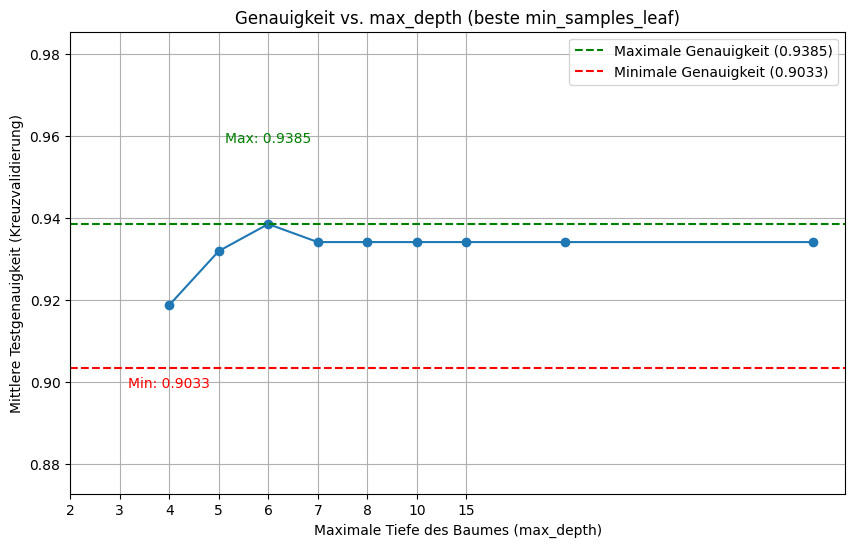


Heatmap der Genauigkeit für alle Hyperparameter-Kombinationen:


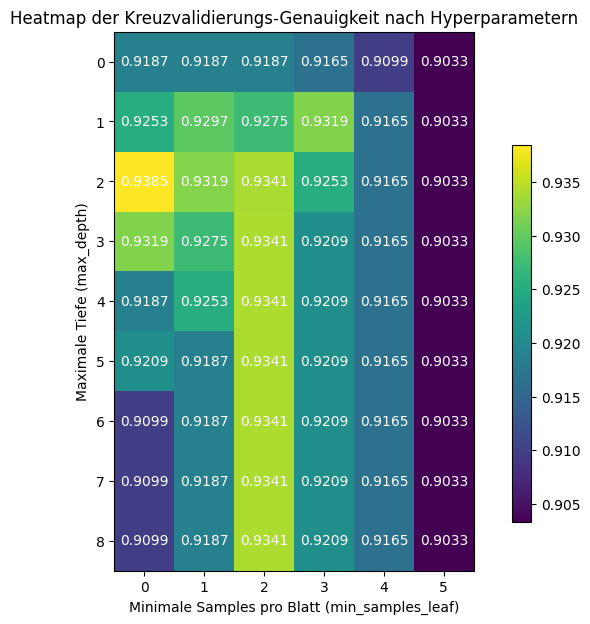

In [7]:
# Aggregiere Ergebnisse nach max_depth, um den besten oder durchschnittlichen Score zu finden
# für jede Tiefe über die verschiedenen min_samples_leaf
grouped_by_max_depth = (
    results_df.groupby("param_max_depth")["mean_test_score"].max().reset_index()
)

# Plotten der Genauigkeit in Abhängigkeit von max_depth
plt.figure(figsize=(10, 6))
plt.plot(
    grouped_by_max_depth["param_max_depth"],
    grouped_by_max_depth["mean_test_score"],
    marker="o",
    linestyle="-",
)

# Beschriftung der X-Achse (anpassen, da None ein String wird)
x_labels = [str(d) for d in grouped_by_max_depth["param_max_depth"]]
plt.xticks(ticks=range(len(x_labels)), labels=x_labels)


plt.title("Genauigkeit vs. max_depth (beste min_samples_leaf)")
plt.xlabel("Maximale Tiefe des Baumes (max_depth)")
plt.ylabel("Mittlere Testgenauigkeit (Kreuzvalidierung)")
plt.ylim(
    min(grouped_by_max_depth["mean_test_score"]) * 0.95,
    max(grouped_by_max_depth["mean_test_score"]) * 1.05,
)  # Anpassung der Y-Achse

# Min/Max Punkte hervorheben
min_accuracy_idx = grouped_by_max_depth["mean_test_score"].idxmin()
max_accuracy_idx = grouped_by_max_depth["mean_test_score"].idxmax()

min_depth = grouped_by_max_depth.loc[min_accuracy_idx, "param_max_depth"]
max_depth = grouped_by_max_depth.loc[max_accuracy_idx, "param_max_depth"]

plt.axhline(
    best_score,
    color="green",
    linestyle="--",
    label=f"Maximale Genauigkeit ({best_score:.4f})",
)
plt.axhline(
    worst_score,
    color="red",
    linestyle="--",
    label=f"Minimale Genauigkeit ({worst_score:.4f})",
)

plt.text(
    grouped_by_max_depth["param_max_depth"].iloc[min_accuracy_idx],
    grouped_by_max_depth["mean_test_score"].min() - 0.02,
    f"Min: {worst_score:.4f}",
    color="red",
    ha="center",
)
plt.text(
    grouped_by_max_depth["param_max_depth"].iloc[max_accuracy_idx],
    grouped_by_max_depth["mean_test_score"].max() + 0.02,
    f"Max: {best_score:.4f}",
    color="green",
    ha="center",
)

plt.legend()
plt.grid(True)
plt.show()

# Zusätzliche Visualisierung: Heatmap für beide Hyperparameter
print("\nHeatmap der Genauigkeit für alle Hyperparameter-Kombinationen:")
pivot_table = results_df.pivot_table(
    values="mean_test_score", index="param_max_depth", columns="param_min_samples_leaf"
)
heatmap_values = np.array(pivot_table)

plt.figure(figsize=(10, 7))
heatmap = plt.imshow(heatmap_values)
for i in range(heatmap_values.shape[0]):
    for j in range(heatmap_values.shape[1]):
        text = plt.text(
            j, i, np.round(heatmap_values[i, j], 4), ha="center", va="center", color="w"
        )

plt.title("Heatmap der Kreuzvalidierungs-Genauigkeit nach Hyperparametern")
plt.xlabel("Minimale Samples pro Blatt (min_samples_leaf)")
plt.ylabel("Maximale Tiefe (max_depth)")
plt.colorbar(heatmap, location="right", anchor=(0, 0.3), shrink=0.7)
plt.show()
